In [1]:
# --- Import check for OpenBNSL ---
try:
    import openbnsllib
    print("✓ Successfully imported openbnsllib")

    # where the module was loaded from
    import os
    print("  - Module file:", getattr(openbnsllib, "__file__", "<no __file__>"))

    # optional attributes
    print("  - cuda_enabled :", getattr(openbnsllib, "cuda_enabled", None))

except Exception as e:
    print("✗ Failed to import openbnsllib")
    print("  Error:", e)
    raise

✓ Successfully imported openbnsllib
  - Module file: /usr/local/lib/python3.10/dist-packages/openbnsllib.cpython-310-x86_64-linux-gnu.so
  - cuda_enabled : False


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


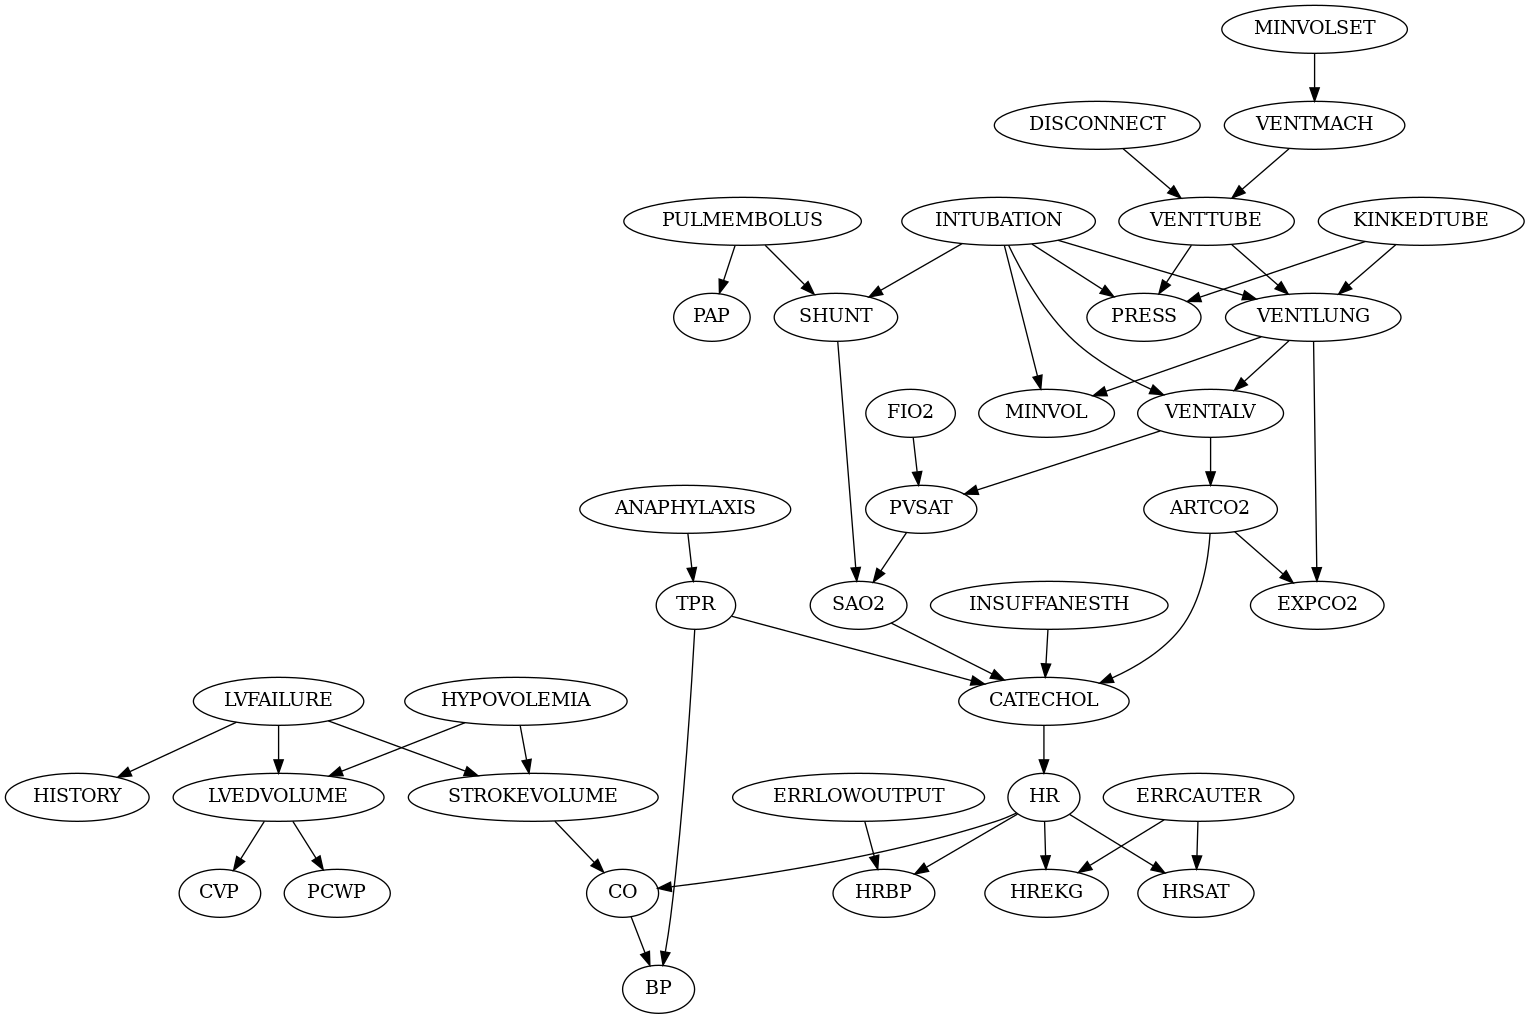

In [2]:
# --- Visualize the original example model ---
from pgmpy.utils import get_example_model
from IPython.display import Image

# model_name = "child"
model_name = "alarm"
# model_name = "insurance"

# Get the original model
original_model = get_example_model(model_name)

# Save the original model as an image
original_model.to_graphviz().draw("original_model.png", prog="dot")

# Display the original model
Image("original_model.png")

In [3]:
# --- Load benchmark samples and wrap for OpenBNSL ---

from helpers.data_cache import get_samples_head

num_samples = int(2e5)   # you can reduce this for notebook use
seed = 0

# Generator function (used only if the cache file does not exist yet)
def _generator(ns, sd):
    return original_model.simulate(ns, seed=sd)

# Load cached samples (or generate+cache automatically)
samples = get_samples_head(
  model_name=model_name,
  seed=seed,
  num_samples=num_samples,
  generator=_generator,
  compress=True,    # same default as benchmark
)

# Ensure stable column order (optional)
samples = samples[sorted(samples.columns)]

# Wrap for OpenBNSL backend
df_wrapper = openbnsllib.base.DataframeWrapper(samples)

print("✓ Loaded samples from cache")
print("  - num_vars:", df_wrapper.num_vars)
print("  - num_samples:", df_wrapper.num_datapoints)


Using cached samples for model 'alarm' with seed 0.
✓ Loaded samples from cache
  - num_vars: 37
  - num_samples: 200000


In [4]:
# --- Choose CI test type ---

from helpers.pgmpy_bridge import to_openbnsl

ci_name = "chi2"
# ci_name = "g2"
# ci_name = "oracle"
alpha = 0.05

if ci_name == "chi2":
  citest_type = openbnsllib.citest.ChiSquare(alpha)
elif ci_name == "g2":
  citest_type = openbnsllib.citest.GSquare(alpha)
elif ci_name == "oracle":
  # Oracle CI test based on the d-separation in the original model
  oracle_graph = to_openbnsl(original_model, df_wrapper.col_str2idx)
  citest_type = openbnsllib.citest.OracleGraph(oracle_graph)
else:
  raise ValueError("unknown CI test:", ci_name)

citest_type

ChiSquare(level=0.050000)

In [5]:
# --- Run PC algorithm ---
import time

start = time.perf_counter()
learned_pdag_obnsl = openbnsllib.structure_learning.pc_edge_parallel(
  df_wrapper,
  citest_type,
  max_cond_vars=len(samples.columns),
)
elapsed = time.perf_counter() - start

print("✓ PC algorithm finished in %.2f seconds" % elapsed)

✓ PC algorithm finished in 0.96 seconds


[INFO][2025-11-20 14:17:22.720] /workspace/src/structure_learning/pc_edge_parallel.cpp:112 (build_skeleton) [PC] order=0, edges removed=388/944, time=0.0717359s
[INFO][2025-11-20 14:17:23.116] /workspace/src/structure_learning/pc_edge_parallel.cpp:112 (build_skeleton) [PC] order=1, edges removed=195/4189, time=0.395658s
[INFO][2025-11-20 14:17:23.459] /workspace/src/structure_learning/pc_edge_parallel.cpp:112 (build_skeleton) [PC] order=2, edges removed=36/1755, time=0.343644s
[INFO][2025-11-20 14:17:23.571] /workspace/src/structure_learning/pc_edge_parallel.cpp:112 (build_skeleton) [PC] order=3, edges removed=2/203, time=0.111678s
[INFO][2025-11-20 14:17:23.600] /workspace/src/structure_learning/pc_edge_parallel.cpp:112 (build_skeleton) [PC] order=4, edges removed=0/40, time=0.0291837s
[INFO][2025-11-20 14:17:23.607] /workspace/src/structure_learning/pc_edge_parallel.cpp:112 (build_skeleton) [PC] order=5, edges removed=1/6, time=0.00623165s
[INFO][2025-11-20 14:17:23.607] /workspace/s

In [6]:
# --- Evaluate learned structure ---

from helpers.pgmpy_bridge import to_pgmpy
from helpers.structural_distance import structural_errors, PDAG2CPDAG

# Convert larned model to CPDAG
learned_pdag_pgmpy = to_pgmpy(learned_pdag_obnsl, list(samples.columns))
learned_cpdag_pgmpy = PDAG2CPDAG(learned_pdag_pgmpy)

structural_errors = structural_errors(
  original_model,
  learned_cpdag_pgmpy,
)

print("✓ Structural errors:" , structural_errors)

✓ Structural errors: {'EE': 0, 'ME': 2, 'ED': 0, 'MD': 0, 'RD': 0, 'SHD': 2}


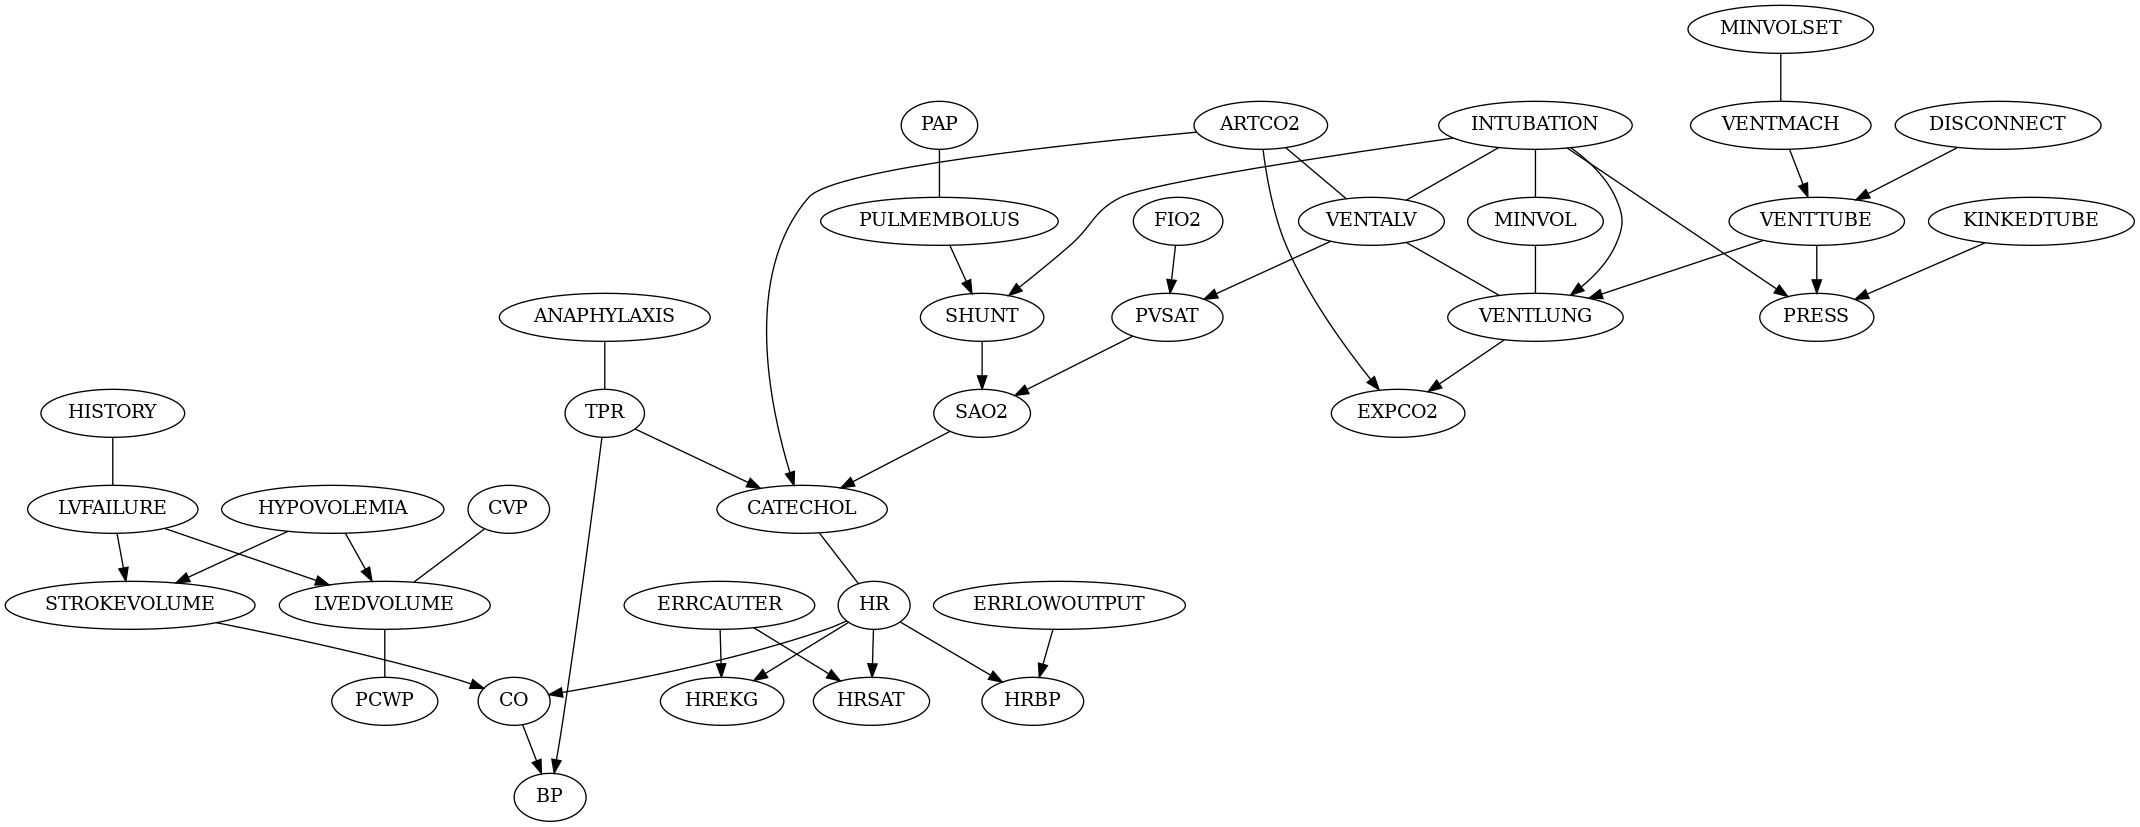

In [7]:
# --- Visualize learned PDAG ---

import pygraphviz as pgv

def draw_pdag(pdag, filename):
    edges = list(pdag.edges())
    directed_edges = []
    undirected_edges = set()

    for u, v in edges:
        if (v, u) in edges:
            undirected_edges.add(tuple(sorted((u, v))))
        else:
            directed_edges.append((u, v))

    lines = ["digraph G {"]
    for u, v in directed_edges:
        lines.append(f'    "{u}" -> "{v}";')
    for u, v in undirected_edges:
        lines.append(f'    "{u}" -> "{v}" [dir=none];')
    lines.append("}")
    dot_str = "\n".join(lines)

    A = pgv.AGraph(string=dot_str)
    A.draw(filename, prog="dot")

draw_pdag(learned_cpdag_pgmpy, "learned_cpdag.png")

Image("learned_cpdag.png")

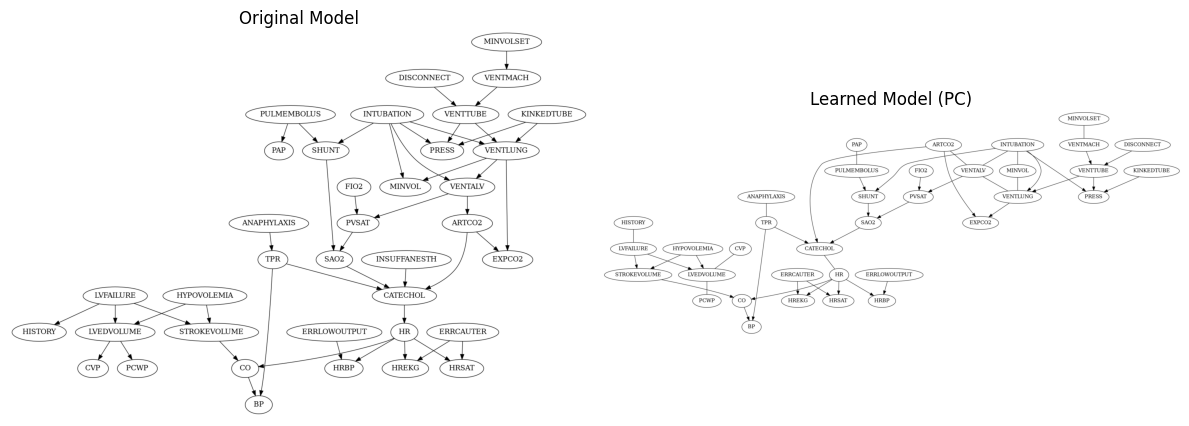

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread("original_model.png")
img2 = mpimg.imread("learned_cpdag.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img1)
axes[0].set_title("Original Model")
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].set_title("Learned Model (PC)")
axes[1].axis("off")
  
plt.tight_layout()
plt.show()